In [51]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [4]:
#Loading and reading the file.
insurance = pd.read_csv('insurance.csv')

In [5]:
#Creating a copy of the dataset.
insurance_copy = insurance.copy()

In [6]:
#View of the dataset.
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
#Renaming the columns name.
insurance.columns= ['Age','Sex','BMI','Children','Smoker','Region','Charges']

In [10]:
insurance.Charges = insurance.Charges.round(2)

In [11]:
#Feature Engineering: Categorical conversion.
insurance.Region.unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [12]:
#One-hot for low-cardinality nominal columns
region_dummies = pd.get_dummies(insurance['Region'].astype(str))

In [13]:
region_dummies

,northeast,northwest,southeast,southwest
0,False,False,False,True
1,False,False,True,False
2,False,False,True,False
3,False,True,False,False
4,False,True,False,False
...,...,...,...,...
1333,False,True,False,False
1334,True,False,False,False
1335,False,False,True,False
1336,False,False,False,True


In [14]:
#Binary mappings
insurance.Sex = insurance.Sex.map({'male':0,'female':1})

insurance.Smoker = insurance.Smoker.map({'no':0,'yes':1})

In [15]:
print(insurance.Sex,insurance.Smoker)

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    1
1335    1
1336    1
1337    1
Name: Sex, Length: 1338, dtype: int64 0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: Smoker, Length: 1338, dtype: int64


In [16]:
#Joining the encoded to the dataset.
insurance = pd.concat((insurance,region_dummies),axis=1)

In [17]:
#Dropping the region column.
insurance.drop(columns='Region',inplace=True)

In [18]:
insurance

,Age,Sex,BMI,Children,Smoker,Charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,16884.92,False,False,False,True
1,18,0,33.770,1,0,1725.55,False,False,True,False
2,28,0,33.000,3,0,4449.46,False,False,True,False
3,33,0,22.705,0,0,21984.47,False,True,False,False
4,32,0,28.880,0,0,3866.86,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.55,False,True,False,False
1334,18,1,31.920,0,0,2205.98,True,False,False,False
1335,18,1,36.850,0,0,1629.83,False,False,True,False
1336,21,1,25.800,0,0,2007.94,False,False,False,True


<Figure size 1500x800 with 0 Axes>

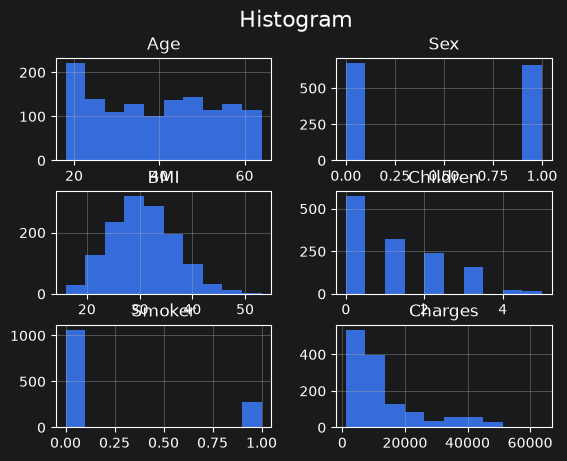

In [43]:
#Exploratory Data Analysis.
#Univariant:Histogram for distribution.
plt.figure(figsize=(15,8))#Set the size of the plot.
insurance.hist()
plt.suptitle('Histogram', fontsize=16)
plt.show();


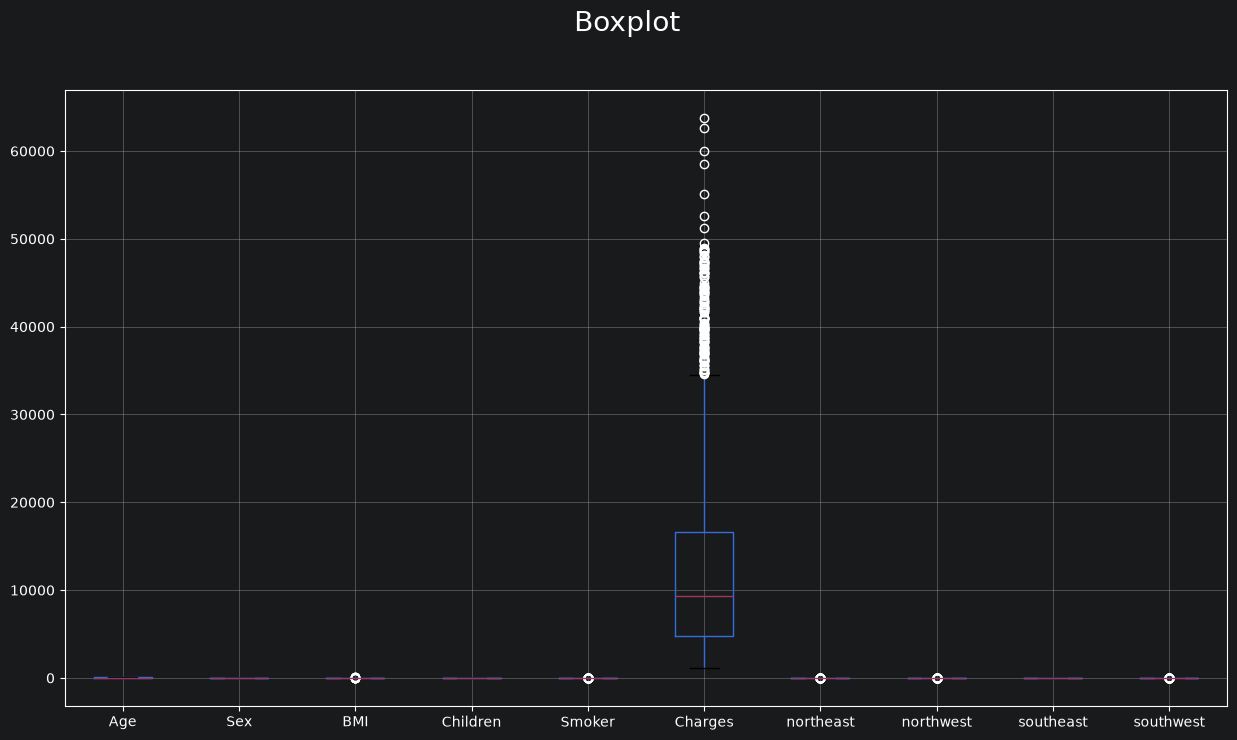

In [30]:
#Boxplot for Outliers: check reasons for outliers?
plt.figure(figsize=(15,8))#Set the size of the plot.
insurance.boxplot()
plt.suptitle('Boxplot', fontsize=20)
plt.show();


In [34]:
#Multivariant: correlation and heatmap for visualization.
corr = insurance.corr()
print(corr)


                Age       Sex       BMI  Children    Smoker   Charges  \
Age        1.000000  0.020856  0.109272  0.042469 -0.025019  0.299008   
Sex        0.020856  1.000000 -0.046371 -0.017163 -0.076185 -0.057292   
BMI        0.109272 -0.046371  1.000000  0.012759  0.003750  0.198341   
Children   0.042469 -0.017163  0.012759  1.000000  0.007673  0.067998   
Smoker    -0.025019 -0.076185  0.003750  0.007673  1.000000  0.787251   
Charges    0.299008 -0.057292  0.198341  0.067998  0.787251  1.000000   
northeast  0.002475  0.002425 -0.138156 -0.022808  0.002811  0.006349   
northwest -0.000407  0.011156 -0.135996  0.024806 -0.036945 -0.039905   
southeast -0.011642 -0.017117  0.270025 -0.023066  0.068498  0.073982   
southwest  0.010016  0.004184 -0.006205  0.021914 -0.036945 -0.043210   

           northeast  northwest  southeast  southwest  
Age         0.002475  -0.000407  -0.011642   0.010016  
Sex         0.002425   0.011156  -0.017117   0.004184  
BMI        -0.138156  -0.135

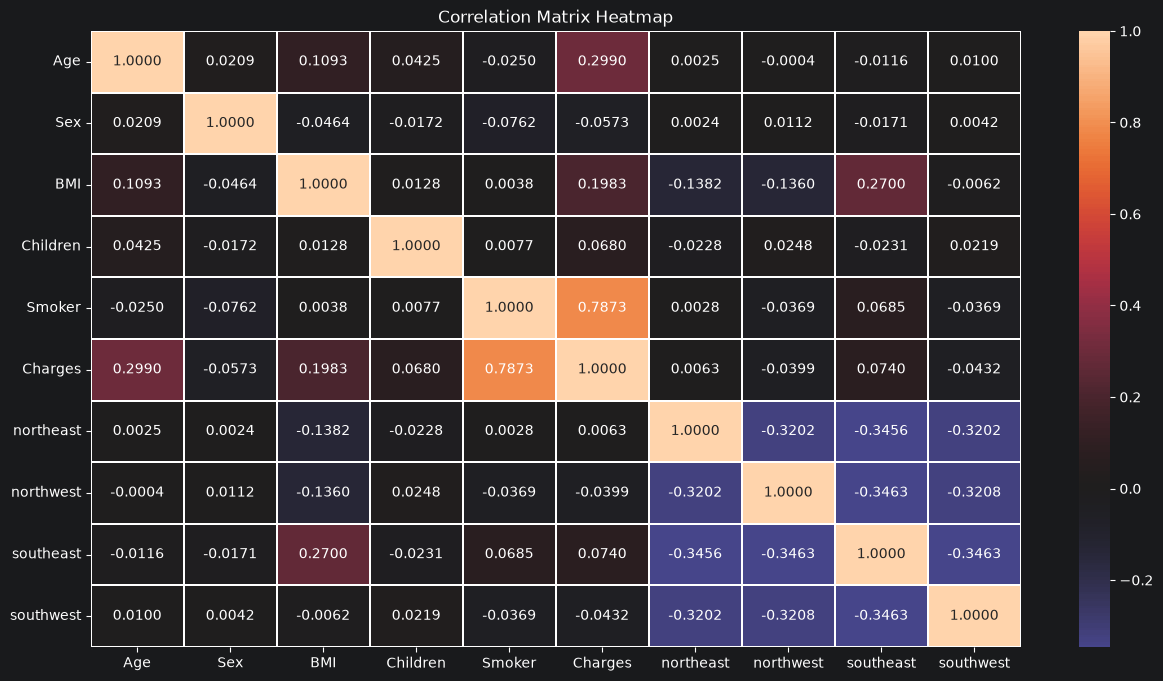

In [44]:
#Correlation heatmap
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, fmt='.4f', center=0,linewidths=.3)
plt.title('Correlation Matrix Heatmap')
plt.show();

In [45]:
'''Testing the pair plot.
from which module will I see the scatter_matrix for pair plot.'''

ModuleNotFoundError: No module named 'pandas.tools'

In [ ]:
'''Save dataset to file.
insurance.write_to_csv'''

In [ ]:
#Model training: import module
from sklearn.model_selection import train_test_split

In [47]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        1338 non-null   int64  
 1   Sex        1338 non-null   int64  
 2   BMI        1338 non-null   float64
 3   Children   1338 non-null   int64  
 4   Smoker     1338 non-null   int64  
 5   Charges    1338 non-null   float64
 6   northeast  1338 non-null   bool   
 7   northwest  1338 non-null   bool   
 8   southeast  1338 non-null   bool   
 9   southwest  1338 non-null   bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 68.1 KB


In [49]:
#Assign variables.

x = insurance[['Age','Sex','BMI','Children','Smoker','northeast','northwest','southeast','southwest']]
y = insurance['Charges']

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=42)

In [54]:
from sklearn.ensemble import RandomForestRegressor#don't understand from here down.
model = RandomForestRegressor(n_estimators=100,random_state=42).fit(x_train,y_train)

In [62]:
y_pred = model.predict(x_test)

print(y_pred)

[ 9807.4932   5333.3392  27996.5237  13023.2128  34671.8855   8383.1224
  2075.3618  14381.3687   6227.2549  10655.2632  19681.0031   7133.0347
  4696.9099  46243.8426  48448.5304  45700.6221   9963.1651  43517.0613
  9236.5649  24211.7397   6008.7592   9913.2847   1852.9054   2486.8361
 11964.8932  12255.0861  13388.9019   6148.2058  10346.4382   5799.7007
  7744.706   11726.3523   3481.6675   5542.1707   3377.5705  10670.0436
  2690.613    8192.9273  23500.1781  39475.1919   6395.3588   2882.4921
 12010.3943  14690.0618   5966.5325  14820.9621  15510.7375   5834.3571
 42101.6622   7053.2181  13941.9543   2758.2925   6655.3558   1833.2962
 13338.3272  10361.8011   3687.8504  45169.5726  12229.5145  15311.564
 13787.6297   7585.5921  20643.7112   7472.5029  12661.0839   5805.2338
 17627.2484  15306.9481   7744.7425   2543.9687   7689.218   10913.4345
  9290.1439  12783.9517   9138.1194   5115.0171   8344.4021  12785.6657
  4191.7457  10434.2752   2021.9957  27693.6635   6658.0965  3752

In [63]:
#Evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error,root_mean_squared_error

In [64]:
rmse = root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [65]:
print(r2)
print(rmse)
print(mae)

0.8622575659980845
4624.320327987735
2580.0313473134333
